In [7]:
# CELL 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c8cde8",
    "xtick.color":      "#6b7194",
    "ytick.color":      "#6b7194",
    "text.color":       "#c8cde8",
    "grid.color":       "#2e3250",
    "grid.linewidth":   0.6,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#2e3250",
    "font.family":      "monospace",
})
 
ACCENT   = "#7c6af7"   # purple  — SoC
WARM     = "#f97066"   # coral   — temperature
TEAL     = "#34d4a0"   # teal    — SoH
AMBER    = "#fbbf24"   # amber   — current / highlights
MUTED    = "#6b7194"   # muted   — secondary info

In [12]:
# CELL 2 — Predictor state (replace with real Predictor output)
transformer_state = {
    "soc":        0.42,
    "soh":        0.93,
    "temp":       305.0,   # Kelvin
    "confidence": 0.06
}
 
print("Predictor state received:")
for k, v in transformer_state.items():
    print(f"  {k:>12}: {v}")

Predictor state received:
           soc: 0.42
           soh: 0.93
          temp: 305.0
    confidence: 0.06


In [ ]:
# CELL 3 — Battery & safety parameters
# R0, R1, C1 aligned with ECM.ipynb fitted values; capacity corrected to 2.3 Ah (NASA spec)
BATTERY_PARAMS = {
    "capacity_Ah": 2.3,    # NASA Li-ion rated capacity (corrected from 2.0)
    "R0_nominal":  0.02,   # Ohm — ohmic resistance (from ECM.ipynb R0_init)
    "R1_nominal":  0.01,   # Ohm — RC branch resistance (from ECM.ipynb)
    "C1_nominal":  2000.0, # F   — RC branch capacitance (from ECM.ipynb)
    "V_max":       4.2,
    "V_min":       3.0,
    "V_cutoff":    2.7,    # hard discharge cutoff (from ECM.ipynb)
    "T_amb":       298.0,   # K  (25 °C)
    "T_max":       333.0,   # K  (60 °C)
    "R_th":        2.0,
    "C_th":        400.0,
    "dt":          1.0      # seconds
}

In [ ]:
# CELL 4 — Physics model
# BatteryECM: first-order RC ECM ported from ECM.ipynb (Cell 5).
# OCV: 5th-degree polynomial fitted from NASA data (ECM.ipynb Cell 12);
#      analytical fallback used here since raw cycle CSVs may not be present.


def ocv_function(soc):
    """Analytical OCV approximation (matches pipeline fallback).
    Replace coeffs with np.poly1d output from ECM.ipynb Cell 12 for
    higher fidelity when the processed cycle CSVs are available."""
    soc = np.clip(soc, 0.0, 1.0)
    return 3.0 + 1.2*soc - 0.3*np.exp(-5*soc) + 0.1*np.exp(-5*(1 - soc))


class BatteryECM:
    """
    First-order RC Equivalent Circuit Model.
    Ported directly from ECM.ipynb Cell 5.

    State variables
    ---------------
    SOC  : state of charge [0, 1]
    V_RC : voltage across RC branch (transient polarisation)

    Convention: I > 0 = charging current.
    """
    def __init__(self, Q, R0, R1, C1, dt, ocv_func, soc_init=1.0):
        self.Q        = Q         # effective capacity in Ah
        self.R0       = R0        # ohmic resistance (Ω)
        self.R1       = R1        # RC branch resistance (Ω)
        self.C1       = C1        # RC branch capacitance (F)
        self.dt       = dt
        self.ocv_func = ocv_func
        self.SOC      = soc_init
        self.V_RC     = 0.0       # initialise at rest

    def step(self, I):
        """Advance one timestep. Returns (SOC, V_RC, OCV, V_terminal)."""
        # SOC update — capacity derated by SoH baked into self.Q
        self.SOC += (I * self.dt) / (3600.0 * self.Q)
        self.SOC  = np.clip(self.SOC, 0.0, 1.0)

        # RC branch dynamics (ECM.ipynb Cell 5)
        alpha     = np.exp(-self.dt / (self.R1 * self.C1))
        self.V_RC = alpha * self.V_RC + self.R1 * (1.0 - alpha) * I

        # Terminal voltage
        OCV   = self.ocv_func(self.SOC)
        V_ecm = OCV - I * self.R0 - self.V_RC
        return self.SOC, self.V_RC, OCV, V_ecm


def thermal_step(temp, current, R0, params, dt):
    """Newton cooling + ohmic heating."""
    heat_gen  = (current ** 2) * R0
    heat_loss = (temp - params["T_amb"]) / params["R_th"]
    return temp + (dt / params["C_th"]) * (heat_gen - heat_loss)


def degradation_step(soh, current, temp, dt):
    """Stress-based SoH degradation proxy."""
    stress = abs(current) * max(0.0, temp - 298.0)
    return max(0.0, soh - 5e-9 * stress * dt)


In [ ]:
# CELL 5 — Simulation engine
def simulate_charging(profile, state, params, log_trajectory=False):
    """
    Forward-simulate a charging profile from the given battery state
    using the first-order RC BatteryECM.
    Returns None if safety limits are breached mid-simulation.
    """
    if state.get("confidence", 0) > 0.15:
        print("  [SIM] Warning: predictor confidence low — trajectory may be unreliable")

    soc  = state["soc"]
    soh  = state["soh"]
    temp = state["temp"]
    dt   = params["dt"]

    # Build ECM instance; derate capacity and scale R0 by SoH
    Q  = params["capacity_Ah"] * max(soh, 0.01)
    R0 = params["R0_nominal"]  / max(soh, 0.01)
    ecm = BatteryECM(
        Q=Q, R0=R0,
        R1=params["R1_nominal"],
        C1=params["C1_nominal"],
        dt=dt, ocv_func=ocv_function, soc_init=soc
    )

    soc_traj, temp_traj, soh_traj, volt_traj = [], [], [], []

    for current in profile:
        soc, V_RC, OCV, voltage = ecm.step(current)

        # Update SoH and recompute R0 for thermal step
        soh = degradation_step(soh, current, temp, dt)
        R0_current = params["R0_nominal"] / max(soh, 0.01)
        temp = thermal_step(temp, current, R0_current, params, dt)

        if voltage > params["V_max"] or temp > params["T_max"]:
            return None

        if log_trajectory:
            soc_traj.append(soc)
            temp_traj.append(temp)
            soh_traj.append(soh)
            volt_traj.append(voltage)

    charging_time = len(profile) * dt
    soh_loss      = state["soh"] - soh

    if log_trajectory:
        return charging_time, soh_loss, soc_traj, temp_traj, soh_traj, volt_traj
    return charging_time, temp, soh_loss, soc


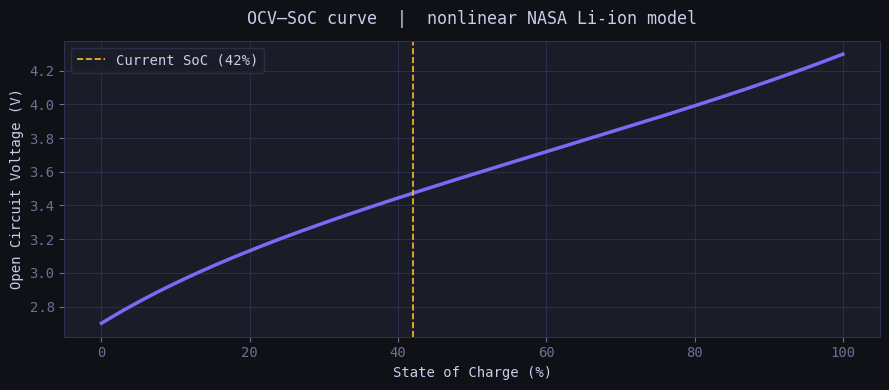

In [16]:
# CELL 6 — OCV curve visualisation
soc_range = np.linspace(0, 1, 200)
ocv_range = [ocv_function(s) for s in soc_range]
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(soc_range * 100, ocv_range, color=ACCENT, lw=2.5)
ax.axvline(transformer_state["soc"] * 100, color=AMBER, lw=1.2,
           linestyle="--", label=f"Current SoC ({transformer_state['soc']:.0%})")
ax.set_xlabel("State of Charge (%)")
ax.set_ylabel("Open Circuit Voltage (V)")
ax.set_title("OCV–SoC curve  |  nonlinear NASA Li-ion model", pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [17]:
# CELL 7 — Fitness function
def fitness_function(sim_result):
    if sim_result is None:
        return -1e6
    charging_time, peak_temp, soh_loss, final_soc = sim_result
    soc_gain     = final_soc - transformer_state["soc"]
    temp_penalty = max(0.0, peak_temp - 318.0)
    return 100.0 * soc_gain - 1e4 * soh_loss - 10.0 * temp_penalty

In [18]:
# CELL 8 — GA hyperparameters & helpers
POP_SIZE     = 40
N_GENERATIONS = 25
HORIZON_SEC  = 1200
DT           = 1.0
N_GENES      = int(HORIZON_SEC / DT)
I_MIN, I_MAX = 0.5, 4.0
ELITE_FRAC   = 0.2
MUT_PROB     = 0.1
MUT_STD      = 0.3
 
 
def initialize_population():
    return [np.random.uniform(I_MIN, I_MAX, N_GENES) for _ in range(POP_SIZE)]
 
 
def crossover(p1, p2):
    pt = np.random.randint(1, N_GENES - 1)
    return np.concatenate([p1[:pt], p2[pt:]])
 
 
def mutate(ind):
    mask = np.random.rand(len(ind)) < MUT_PROB
    ind[mask] += np.random.normal(0, MUT_STD, mask.sum())
    return np.clip(ind, I_MIN, I_MAX)

In [19]:
# CELL 9 — Run GA
print("Running Genetic Algorithm...")
population            = initialize_population()
best_fitness_history  = []
mean_fitness_history  = []
 
for gen in range(N_GENERATIONS):
    fitnesses = np.array([
        fitness_function(simulate_charging(ind, transformer_state, BATTERY_PARAMS))
        for ind in population
    ])
 
    best_fitness_history.append(fitnesses.max())
    mean_fitness_history.append(fitnesses[fitnesses > -1e5].mean()
                                if (fitnesses > -1e5).any() else 0)
 
    elite_count = int(ELITE_FRAC * POP_SIZE)
    elites      = [population[i] for i in np.argsort(fitnesses)[-elite_count:]]
 
    next_pop = elites.copy()
    while len(next_pop) < POP_SIZE:
        i1, i2 = np.random.choice(len(elites), 2, replace=False)
        child   = mutate(crossover(elites[i1], elites[i2]))
        next_pop.append(child)
    population = next_pop
 
    print(f"  Gen {gen+1:2d}/{N_GENERATIONS} | best={best_fitness_history[-1]:.2f} | mean={mean_fitness_history[-1]:.2f}")
 
fitnesses   = np.array([
    fitness_function(simulate_charging(ind, transformer_state, BATTERY_PARAMS))
    for ind in population
])
best_profile = population[np.argmax(fitnesses)]
print("\nGA complete.")

Running Genetic Algorithm...
  Gen  1/25 | best=-1000000.00 | mean=0.00
  Gen  2/25 | best=39.35 | mean=39.19
  Gen  3/25 | best=39.35 | mean=39.18
  Gen  4/25 | best=39.44 | mean=39.27
  Gen  5/25 | best=39.44 | mean=39.30
  Gen  6/25 | best=39.46 | mean=39.31
  Gen  7/25 | best=39.48 | mean=39.39
  Gen  8/25 | best=39.55 | mean=39.42
  Gen  9/25 | best=39.55 | mean=39.47
  Gen 10/25 | best=39.56 | mean=39.49
  Gen 11/25 | best=39.61 | mean=39.51
  Gen 12/25 | best=39.65 | mean=39.56
  Gen 13/25 | best=39.65 | mean=39.58
  Gen 14/25 | best=39.65 | mean=39.60
  Gen 15/25 | best=39.70 | mean=39.61
  Gen 16/25 | best=39.75 | mean=39.63
  Gen 17/25 | best=39.82 | mean=39.66
  Gen 18/25 | best=39.85 | mean=39.74
  Gen 19/25 | best=39.85 | mean=39.77
  Gen 20/25 | best=39.93 | mean=39.80
  Gen 21/25 | best=39.97 | mean=39.86
  Gen 22/25 | best=39.97 | mean=39.92
  Gen 23/25 | best=39.98 | mean=39.93
  Gen 24/25 | best=40.00 | mean=39.94
  Gen 25/25 | best=40.00 | mean=39.95

GA complete.


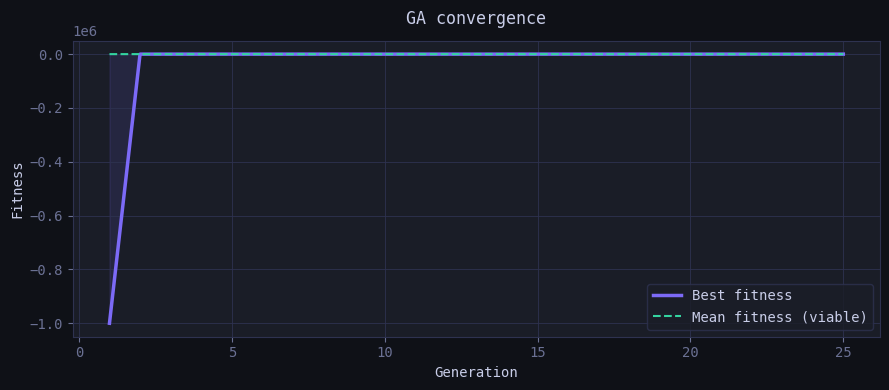

In [20]:
# CELL 10 — GA convergence plot
fig, ax = plt.subplots(figsize=(9, 4))
gens = range(1, N_GENERATIONS + 1)
ax.plot(gens, best_fitness_history, color=ACCENT, lw=2.5, label="Best fitness")
ax.plot(gens, mean_fitness_history, color=TEAL,   lw=1.5,
        linestyle="--", label="Mean fitness (viable)")
ax.fill_between(gens, mean_fitness_history, best_fitness_history,
                alpha=0.12, color=ACCENT)
ax.set_xlabel("Generation")
ax.set_ylabel("Fitness")
ax.set_title("GA convergence", pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

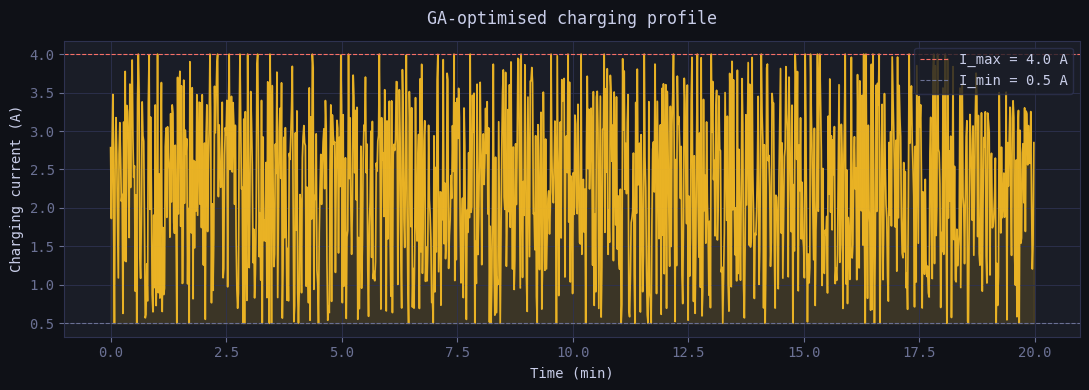

In [21]:
# CELL 11 — GA best profile plot
time_axis = np.arange(N_GENES) / 60   # minutes
 
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(time_axis, best_profile, color=AMBER, lw=1.2, alpha=0.9)
ax.fill_between(time_axis, I_MIN, best_profile, alpha=0.15, color=AMBER)
ax.axhline(I_MAX, color=WARM, lw=0.8, linestyle="--", label=f"I_max = {I_MAX} A")
ax.axhline(I_MIN, color=MUTED, lw=0.8, linestyle="--", label=f"I_min = {I_MIN} A")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Charging current (A)")
ax.set_title("GA-optimised charging profile", pad=12)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# CELL 12 — NSGA-II setup
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
 
 
class ChargingNSGA2Problem(Problem):
    def __init__(self, state):
        super().__init__(n_var=N_GENES, n_obj=3, n_constr=0,
                         xl=I_MIN, xu=I_MAX)
        self.state = state
 
    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        for ind in X:
            sim = simulate_charging(ind, self.state, BATTERY_PARAMS)
            if sim is None:
                F.append([1e3, 1e3, 1e3])
            else:
                charging_time, peak_temp, soh_loss, final_soc = sim
                soc_gain = final_soc - self.state["soc"]
                F.append([-soc_gain, peak_temp, soh_loss])
        out["F"] = np.array(F)

In [23]:
# CELL 13 — Run NSGA-II
print("Running NSGA-II...")
algorithm = NSGA2(
    pop_size=60,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)
 
problem = ChargingNSGA2Problem(transformer_state)
result  = minimize(problem, algorithm, termination=("n_gen", 40),
                   seed=1, verbose=True)
 
pareto_profiles    = result.X
pareto_objectives  = result.F
soc_gain  = -pareto_objectives[:, 0]
peak_temp =  pareto_objectives[:, 1]
soh_loss  =  pareto_objectives[:, 2]
print(f"\nPareto front size: {len(pareto_profiles)} solutions")

Running NSGA-II...
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       60 |     60 |             - |             -
     2 |      120 |     60 |  0.000000E+00 |             f
     3 |      180 |     60 |  0.000000E+00 |             f
     4 |      240 |     60 |  0.000000E+00 |             f
     5 |      300 |      1 |  1.000384E+03 |         ideal
     6 |      360 |      2 |  1.0000000000 |         ideal
     7 |      420 |      3 |  0.2437282899 |         ideal
     8 |      480 |      3 |  0.000000E+00 |             f
     9 |      540 |      6 |  0.7733352179 |         ideal
    10 |      600 |     14 |  0.0683643415 |         ideal
    11 |      660 |     30 |  0.1334876091 |         ideal
    12 |      720 |     53 |  0.0447298062 |         ideal
    13 |      780 |     60 |  0.0575503270 |         ideal
    14 |      840 |     60 |  0.1499226348 |         ideal
    15 |      900 |     60 |  0.1117112355 |         ideal
    16 |      960 |     60 |  0.08124

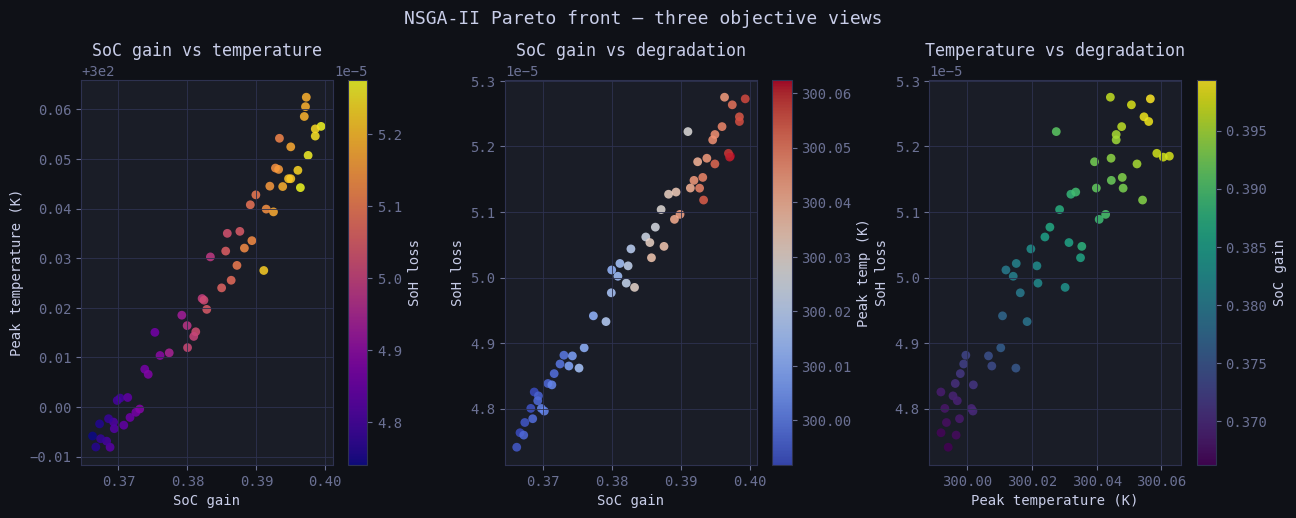

In [24]:
# CELL 14 — Pareto front 3-panel plot
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)
 
# Panel A: SoC gain vs temperature
ax1 = fig.add_subplot(gs[0])
sc1 = ax1.scatter(soc_gain, peak_temp, c=soh_loss,
                  cmap="plasma", s=40, alpha=0.85, edgecolors="none")
plt.colorbar(sc1, ax=ax1, label="SoH loss")
ax1.set_xlabel("SoC gain")
ax1.set_ylabel("Peak temperature (K)")
ax1.set_title("SoC gain vs temperature")
ax1.grid(True)
 
# Panel B: SoC gain vs SoH loss
ax2 = fig.add_subplot(gs[1])
sc2 = ax2.scatter(soc_gain, soh_loss, c=peak_temp,
                  cmap="coolwarm", s=40, alpha=0.85, edgecolors="none")
plt.colorbar(sc2, ax=ax2, label="Peak temp (K)")
ax2.set_xlabel("SoC gain")
ax2.set_ylabel("SoH loss")
ax2.set_title("SoC gain vs degradation")
ax2.grid(True)
 
# Panel C: Temperature vs SoH loss
ax3 = fig.add_subplot(gs[2])
sc3 = ax3.scatter(peak_temp, soh_loss, c=soc_gain,
                  cmap="viridis", s=40, alpha=0.85, edgecolors="none")
plt.colorbar(sc3, ax=ax3, label="SoC gain")
ax3.set_xlabel("Peak temperature (K)")
ax3.set_ylabel("SoH loss")
ax3.set_title("Temperature vs degradation")
ax3.grid(True)
 
fig.suptitle("NSGA-II Pareto front — three objective views", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 15 — Pick representative solutions & rollout
fast_idx     = np.argmax(soc_gain)
gentle_idx   = np.argmin(soh_loss)
balanced_idx = np.argsort(np.abs(soc_gain - np.median(soc_gain)))[0]

selected_profiles = {
    "fast":     pareto_profiles[fast_idx],
    "balanced": pareto_profiles[balanced_idx],
    "gentle":   pareto_profiles[gentle_idx],
}

COLORS = {"fast": WARM, "balanced": ACCENT, "gentle": TEAL}


def rollout(profile, state):
    """Re-simulate a profile using BatteryECM for trajectory logging."""
    soc  = state["soc"]
    soh  = state["soh"]
    temp = state["temp"]
    dt   = BATTERY_PARAMS["dt"]

    Q  = BATTERY_PARAMS["capacity_Ah"] * max(soh, 0.01)
    R0 = BATTERY_PARAMS["R0_nominal"]  / max(soh, 0.01)
    ecm = BatteryECM(
        Q=Q, R0=R0,
        R1=BATTERY_PARAMS["R1_nominal"],
        C1=BATTERY_PARAMS["C1_nominal"],
        dt=dt, ocv_func=ocv_function, soc_init=soc
    )

    soc_t, temp_t, soh_t, volt_t, cur_t = [], [], [], [], []
    for current in profile:
        soc, V_RC, OCV, voltage = ecm.step(current)
        soh  = degradation_step(soh, current, temp, dt)
        R0_c = BATTERY_PARAMS["R0_nominal"] / max(soh, 0.01)
        temp = thermal_step(temp, current, R0_c, BATTERY_PARAMS, dt)
        soc_t.append(soc);  temp_t.append(temp)
        soh_t.append(soh);  volt_t.append(voltage)
        cur_t.append(current)
    return soc_t, temp_t, soh_t, volt_t, cur_t


trajs = {name: rollout(prof, transformer_state)
         for name, prof in selected_profiles.items()}


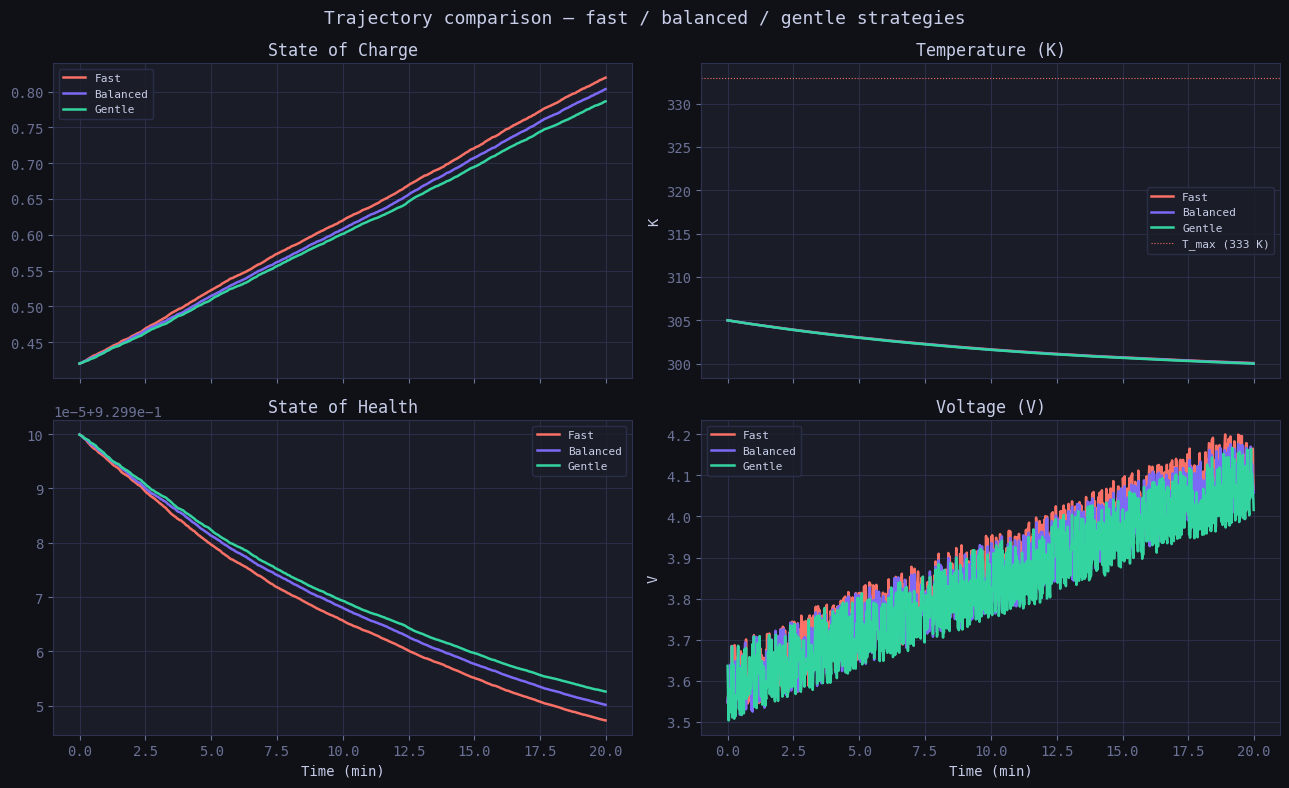

In [26]:
# CELL 16 — Trajectory comparison (4-panel)
t_min = np.arange(N_GENES) / 60
 
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
titles  = ["State of Charge", "Temperature (K)", "State of Health", "Voltage (V)"]
indices = [0, 1, 2, 3]
 
for ax, idx, title in zip(axes.flat, indices, titles):
    for name, traj in trajs.items():
        ax.plot(t_min, traj[idx], color=COLORS[name], lw=1.8,
                label=name.capitalize())
    if idx == 1:   # temperature — safety line
        ax.axhline(333.0, color=WARM, lw=0.8, linestyle=":",
                   label="T_max (333 K)")
    ax.set_title(title)
    ax.set_ylabel(title.split("(")[-1].replace(")", "") if "(" in title else "")
    ax.grid(True)
    ax.legend(fontsize=8)
 
for ax in axes[1]:
    ax.set_xlabel("Time (min)")
 
fig.suptitle("Trajectory comparison — fast / balanced / gentle strategies", fontsize=13)
plt.tight_layout()
plt.show()

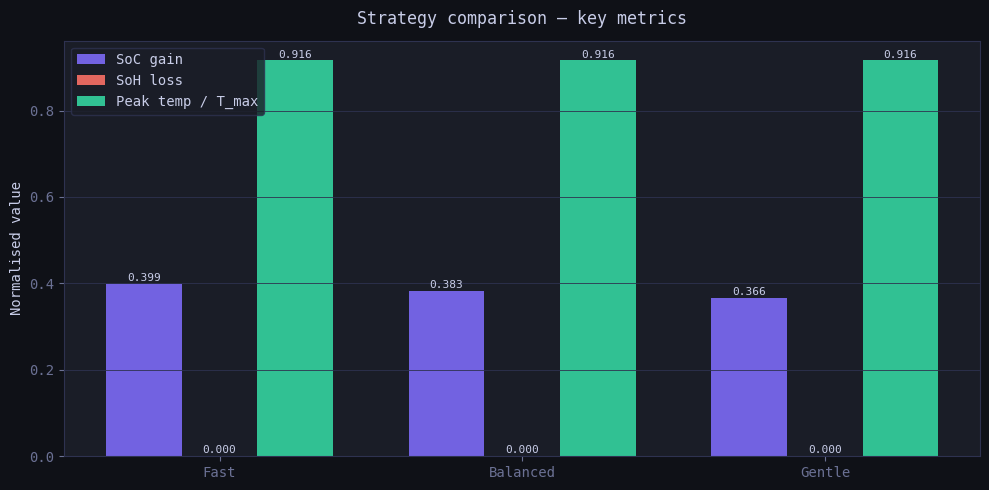

In [27]:
# CELL 17 — Per-strategy summary bar chart
labels   = ["Fast", "Balanced", "Gentle"]
soc_gains_rep = [trajs["fast"][0][-1]     - transformer_state["soc"],
                 trajs["balanced"][0][-1] - transformer_state["soc"],
                 trajs["gentle"][0][-1]   - transformer_state["soc"]]
soh_losses_rep = [transformer_state["soh"] - trajs["fast"][2][-1],
                  transformer_state["soh"] - trajs["balanced"][2][-1],
                  transformer_state["soh"] - trajs["gentle"][2][-1]]
peak_temps_rep = [max(trajs["fast"][1]),
                  max(trajs["balanced"][1]),
                  max(trajs["gentle"][1])]
 
x = np.arange(3)
w = 0.25
 
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w, soc_gains_rep,  w, label="SoC gain",      color=ACCENT, alpha=0.9)
b2 = ax.bar(x,     soh_losses_rep, w, label="SoH loss",      color=WARM,   alpha=0.9)
b3 = ax.bar(x + w, [t/333 for t in peak_temps_rep], w,
            label="Peak temp / T_max", color=TEAL, alpha=0.9)
 
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Normalised value")
ax.set_title("Strategy comparison — key metrics", pad=12)
ax.legend()
ax.grid(True, axis="y")
 
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8, color="#c8cde8")
 
plt.tight_layout()
plt.show()

In [28]:
# CELL 18 — Save dataset for downstream agents
all_rows = []
for sol_id, profile in enumerate(pareto_profiles):
    result = simulate_charging(profile, transformer_state, BATTERY_PARAMS,
                               log_trajectory=True)
    if result is None:
        continue
    _, _, soc_t, temp_t, soh_t, volt_t = result
    for t in range(len(profile)):
        all_rows.append({
            "solution_id":   sol_id,
            "time_s":        t,
            "current_A":     profile[t],
            "SoC":           soc_t[t],
            "temperature_K": temp_t[t],
            "SoH":           soh_t[t],
            "voltage_V":     volt_t[t],
        })
 
df_out = pd.DataFrame(all_rows)
df_out.to_csv("nsga2_synthetic_dataset.csv", index=False)
print(f"Saved {len(df_out):,} rows, {df_out['solution_id'].nunique()} solutions.")
print(df_out.head())

Saved 72,000 rows, 60 solutions.
   solution_id  time_s  current_A       SoC  temperature_K   SoH  voltage_V
0            0       0   1.386470  0.420207     304.991508  0.93   3.547307
1            0       1   1.637465  0.420452     304.983129  0.93   3.561093
2            0       2   1.886302  0.420733     304.974879  0.93   3.574817
3            0       3   1.053187  0.420891     304.966309  0.93   3.530423
4            0       4   1.831087  0.421164     304.958052  0.93   3.572467
